# Ben and Jerry’s ice cream

Hannah Olejniczak  
2025-03-24

Analyzing the ice cream dataframe

In [ ]:
ice_cream <- read_csv('https://bcdanl.github.io/data/ben-and-jerry-cleaned.csv')

First looking at some descriptive statistics

In [ ]:
summary(ice_cream)

   priceper1     flavor_descr       size1_descr         household_id     
 Min.   :0.000   Length:21974       Length:21974       Min.   : 2000358  
 1st Qu.:3.000   Class :character   Class :character   1st Qu.: 8142253  
 Median :3.340   Mode  :character   Mode  :character   Median : 8401573  
 Mean   :3.315                                         Mean   :16612005  
 3rd Qu.:3.590                                         3rd Qu.:30183891  
 Max.   :9.480                                         Max.   :30440689  
 household_income household_size   usecoup          couponper1    
 Min.   : 40000   Min.   :1.000   Mode :logical   Min.   :0.0000  
 1st Qu.: 80000   1st Qu.:2.000   FALSE:19629     1st Qu.:0.0000  
 Median :110000   Median :2.000   TRUE :2345      Median :0.0000  
 Mean   :125291   Mean   :2.456                   Mean   :0.1256  
 3rd Qu.:170000   3rd Qu.:3.000                   3rd Qu.:0.0000  
 Max.   :310000   Max.   :9.000                   Max.   :8.9800  
    region   

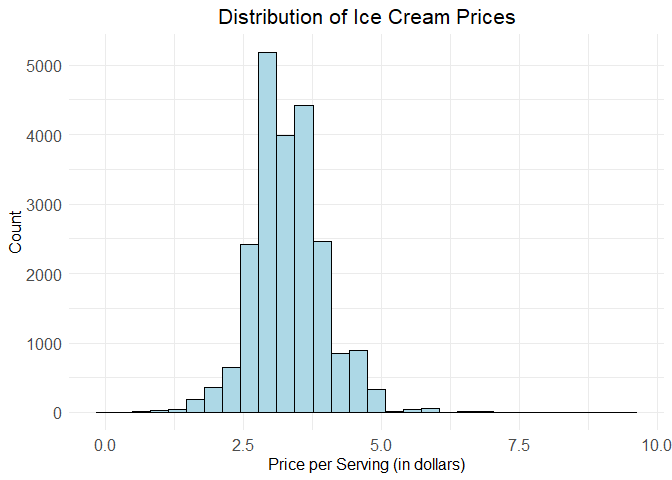

In [ ]:
ggplot(ice_cream, aes(x = priceper1)) +
  geom_histogram(bins = 30, fill = "lightblue", color = "black") +
  labs(title = "Distribution of Ice Cream Prices",
       x = "Price per Serving (in dollars)",
       y = "Count") +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 16, hjust = 0.5),
    axis.title = element_text(size = 12),
    axis.text = element_text(size = 12)
  )

This histogram shows us the distribution of price per serving of all
products.

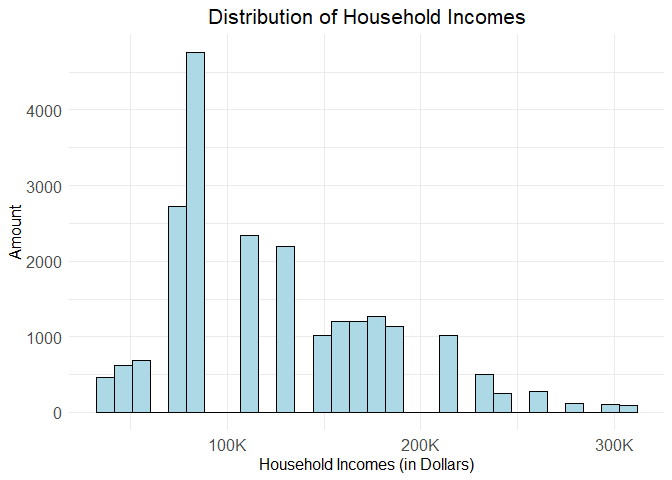

In [ ]:
ggplot(ice_cream, aes(x = household_income)) +
  geom_histogram(bins = 30, fill = "lightblue", color = "black") +
  labs(title = "Distribution of Household Incomes",
       x = "Household Incomes (in Dollars)",
       y = "Amount") +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 16, hjust = 0.5),
    axis.title = element_text(size = 12),
    axis.text = element_text(size = 12)
  ) +
    scale_x_continuous(labels = label_number(scale = 1e-3, suffix = "K"))

This histogram tells us that once a household’s income reaches 200K they
are less likely to purchase Ben and Jerry’s ice cream.

#Looking at the purchasing trends

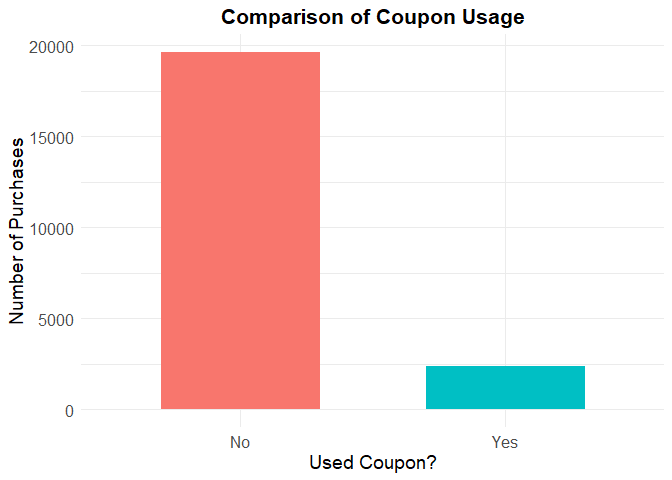

In [ ]:
# Count the number of people who used a coupon vs. those who didn't
coupon_usage <- ice_cream |>
  group_by(usecoup) |>
  summarise(count = n(), .groups = "drop")

# Plot the coupon usage
ggplot(coupon_usage, 
       aes(x = as.factor(usecoup), 
           y = count, 
           fill = as.factor(usecoup))) +
  geom_bar(stat = "identity", width = 0.6) +
  labs(title = "Comparison of Coupon Usage",
       x = "Used Coupon?",
       y = "Number of Purchases") +
  scale_x_discrete(labels = c("FALSE" = "No", "TRUE" = "Yes")) +  
  theme_minimal() +
  theme(
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    axis.title = element_text(size = 14),
    axis.text = element_text(size = 12),
    legend.position = "none"
  )

Here we can see there are not many coupons being used on the ice cream.

#Looking at Regional Ice Cream Trends

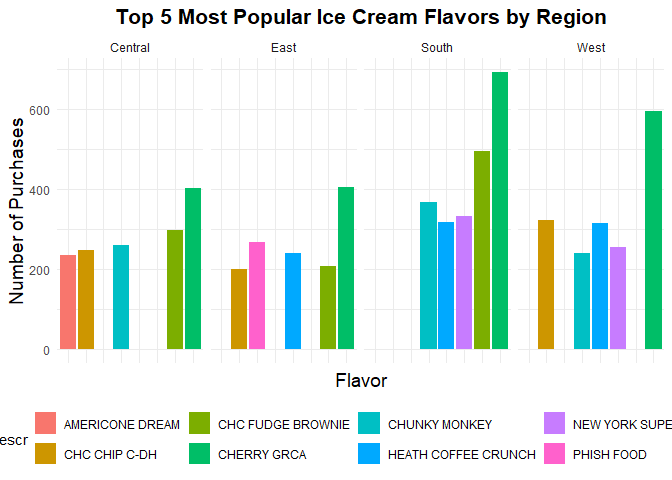

In [ ]:
# Get the top 5 flavors for each region
top_flavors <- ice_cream |>
  group_by(region, flavor_descr) |>
  summarise(count = n(), .groups = "drop") |>
  arrange(region, desc(count)) |>
  group_by(region) |>
  slice_max(order_by = count, n = 5)

ggplot(top_flavors, 
       aes(x = reorder(flavor_descr, count), 
           y = count, 
           fill = flavor_descr)) +
  geom_bar(stat = "identity") +
  facet_wrap(~region, nrow = 1) + 
  labs(title = "Top 5 Most Popular Ice Cream Flavors by Region",
       x = "Flavor",
       y = "Number of Purchases") +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    axis.title = element_text(size = 14),
    axis.text.x = element_blank(),
    legend.position = "bottom"
  )

This plot shows us the most popular ice cream flavors by region. It can
be seen that only one flavor is in the top 5 of all four regions, Cherry
Garcia.